# Módulo 13 · Red densa simple con Keras

Curso: **Series Temporales con R y Python** (Frogames Formación).

Este notebook es el código de acompañamiento de la lección `02-red-densa-con-keras`. Antes de meternos
con RNN/LSTM (siguientes lecciones), practicamos la API básica de Keras 3 (`Sequential`, `Dense`,
`compile`, `fit`, `predict`) sobre un problema de regresión sintético y sencillo: no hay nada de
temporal todavía, solo asentar cómo se construye y entrena una red en Keras 3 antes de pasar a
arquitecturas para secuencias.

## Datos sintéticos: y = 2x + 3 + ruido

Una recta con ruido gaussiano — lo justo para comprobar que la red aprende algo con sentido.

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

m = 2
b = 3
x = np.linspace(0, 50, 100)

np.random.seed(101)
ruido = np.random.normal(loc=0.0, scale=4.0, size=len(x))
y = m * x + b + ruido

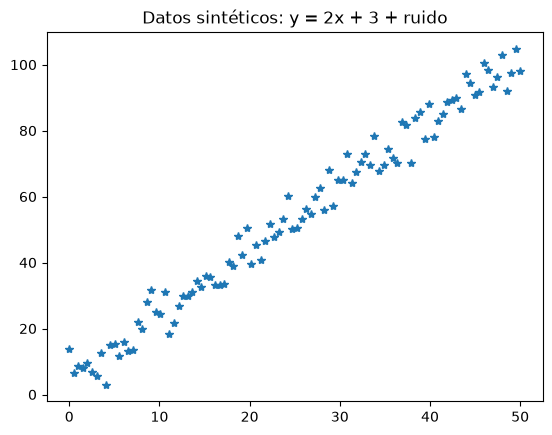

In [2]:
plt.plot(x, y, '*')
plt.title("Datos sintéticos: y = 2x + 3 + ruido")
plt.show()

## Creando una red neuronal para una regresión

Tres capas `Dense`: dos capas ocultas de 4 neuronas con activación `relu`, y una capa de salida de 1
neurona con activación `linear` (porque predecimos un número continuo, no una clase).

In [3]:
keras.utils.set_random_seed(101)

model = Sequential()
model.add(Dense(4, input_dim=1, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam')
model.summary()

/Users/juangabriel/.cache/uv/archive-v0/X3uvbETrRLM9I2Hq/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

**Nota**: en este ejemplo nos saltamos el paso de dividir en train/test — el objetivo es la mecánica de
la API, no evaluar un modelo de producción.

In [4]:
history = model.fit(x, y, epochs=200, verbose=0)

print("loss epoch 1:  ", history.history['loss'][0])
print("loss epoch 50: ", history.history['loss'][49])
print("loss epoch 200:", history.history['loss'][-1])

loss epoch 1:   795.2274780273438
loss epoch 50:  22.815736770629883
loss epoch 200: 20.103748321533203


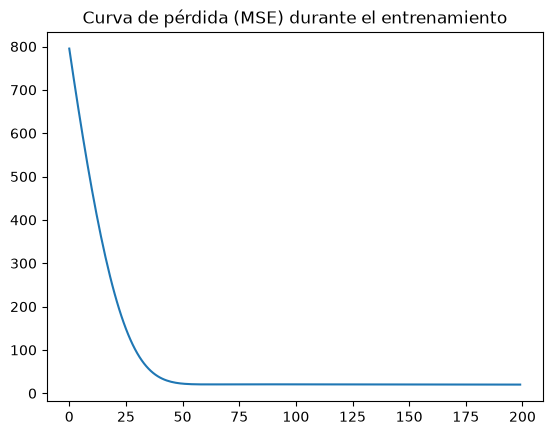

In [5]:
loss = history.history['loss']
epochs = range(len(loss))
plt.plot(epochs, loss)
plt.title("Curva de pérdida (MSE) durante el entrenamiento")
plt.show()

## Prediciendo nuevos puntos con el modelo creado

In [6]:
x_for_predictions = np.linspace(0, 50, 1000)
y_predicted = model.predict(x_for_predictions, verbose=0)

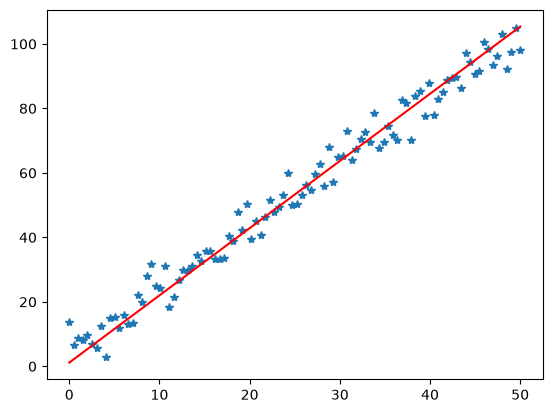

In [7]:
plt.plot(x, y, '*')
plt.plot(x_for_predictions, y_predicted, 'r')
plt.show()

## Evaluando el error

In [8]:
prediction_for_true_y = model.predict(x, verbose=0)

mse = mean_squared_error(y, prediction_for_true_y)
mae = mean_absolute_error(y, prediction_for_true_y)
print("MSE:", mse)
print("MAE:", mae)
print("var(y):", np.var(y))

MSE: 20.09272971394412
MAE: 3.5918592414305532
var(y): 836.0917033544197
